In [27]:
'''
Feature Engineering & Selection on Breast cancer dataset


implement and demonstrate various feature selection algorithms and compare the performance of the 
algorithms.

Feature selection algorithm used:
1)  SelectKBest
2) Recursive feature elimination (RFE)
3) L1-based feature selection (Lasso regularization)
4) Tree-based feature selection


compare  their performance
'''

'\nFeature Engineering & Selection on Breast cancer dataset\n\n\nimplement and demonstrate various feature selection algorithms and compare the performance of the \nalgorithms.\n\nFeature selection algorithm used:\n1)  SelectKBest\n2) Recursive feature elimination (RFE)\n3) L1-based feature selection (Lasso regularization)\n4) Tree-based feature selection\n\n\ncompare  their performance\n'

In [ ]:
'''
feature engineering: everything you do to the raw features before feeding them to the model: cleaning, transforming, creating, selecting, and validating

1) EDA: find missing values, distributions, skewness, correlations, and class balance.
2) Replacing missing values
3) Outlier detection
4) Transformation: models (logistic, linear) perform better if features are approximately normal / linear with target.
5) Scaling: Standardscaller, minmaxscaller etc.
6) Create new features
7) drop related features
8) Feature selection methods
9) Class imbalance
10) Feature importance and explainability

'''

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer 

In [29]:

# Load breast cancer dataset from scikit-learn
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
# assigning it column name - target
y = pd.Series(data.target, name = 'target')

In [30]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
from sklearn.model_selection import StratifiedKFold

# selecting top 5 features 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro',
    'roc_auc': 'roc_auc'
}

from sklearn.ensemble import RandomForestClassifier
# classifier we'll evaluate (final model)
clf = RandomForestClassifier(n_estimators=200, random_state=42)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

from sklearn.model_selection import cross_validate, train_test_split
# created a pipeine for preprocessing and classifier
pipe_baseline = Pipeline([
    ('scaler', StandardScaler()),         # scaling is safe and consistent across pipelines
    ('clf', clf)
])

'''
Cross-validation is a way to evaluate the performance of a model more reliably

Split data into 5 equal parts
Train on 4 parts, test on the 1 remaining part.
Repeat 5 times, each time using a different fold as the test set.
Average the performance across all 5 runs
'''
res_base = cross_validate(pipe_baseline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
# compute mean scores
base_scores = {metric: np.mean(res_base['test_' + metric]) for metric in scoring}
base_scores


{'accuracy': np.float64(0.9543238627542306),
 'precision': np.float64(0.954350717243009),
 'recall': np.float64(0.9502897878225424),
 'f1': np.float64(0.9509490031645764),
 'roc_auc': np.float64(0.9895776684222476)}

In [33]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression


k = 10
n_features_to_select = 10

# 1) Univariate (SelectKBest with mutual information)
pipe_kbest = Pipeline([
    ('scaler', StandardScaler()),
    ('kbest', SelectKBest(score_func=mutual_info_classif, k=k)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

# 2) RFE (wrapper) - use a small RF as the estimator inside RFE
rfe_estimator = RandomForestClassifier(n_estimators=100, random_state=42)
pipe_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('rfe', RFE(estimator=rfe_estimator, n_features_to_select=n_features_to_select, step=1)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

# 3) L1-based selection (LogisticRegression with L1 inside SelectFromModel)
l1_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42),
    threshold='median'   # keep features with coef magnitude > median
)
pipe_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('l1sel', l1_selector),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

# 4) Tree-based SelectFromModel (using RF importances)
tree_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=42),
    threshold='median'
)
pipe_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('treesel', tree_selector),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

pipes = {
    'Baseline_all_features': pipe_baseline,
    'SelectKBest_mutual_info_k=10': pipe_kbest,
    'RFE_RF_n=10': pipe_rfe,
    'L1_SelectFromModel_median': pipe_l1,
    'Tree_SelectFromModel_median': pipe_tree
}

# Evaluate each pipeline with CV (this runs selection inside CV - no leakage)
results = {}
for name, pipe in pipes.items():
    print("Running CV for:", name)
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    # mean of each metric
    results[name] = {metric: np.mean(res['test_' + metric]) for metric in scoring}

results_df = pd.DataFrame(results).T
results_df = results_df[['accuracy','precision','recall','f1','roc_auc']]  # reorder
results_df.round(4)


Running CV for: Baseline_all_features
Running CV for: SelectKBest_mutual_info_k=10
Running CV for: RFE_RF_n=10
Running CV for: L1_SelectFromModel_median
Running CV for: Tree_SelectFromModel_median


,accuracy,precision,recall,f1,roc_auc
Baseline_all_features,0.9543,0.9544,0.9503,0.9509,0.9896
SelectKBest_mutual_info_k=10,0.9491,0.9474,0.9451,0.9454,0.9849
RFE_RF_n=10,0.9473,0.9479,0.9418,0.9433,0.9900
L1_SelectFromModel_median,0.9508,0.9506,0.9455,0.9470,0.9921
Tree_SelectFromModel_median,0.9543,0.9545,0.9493,0.9509,0.9890


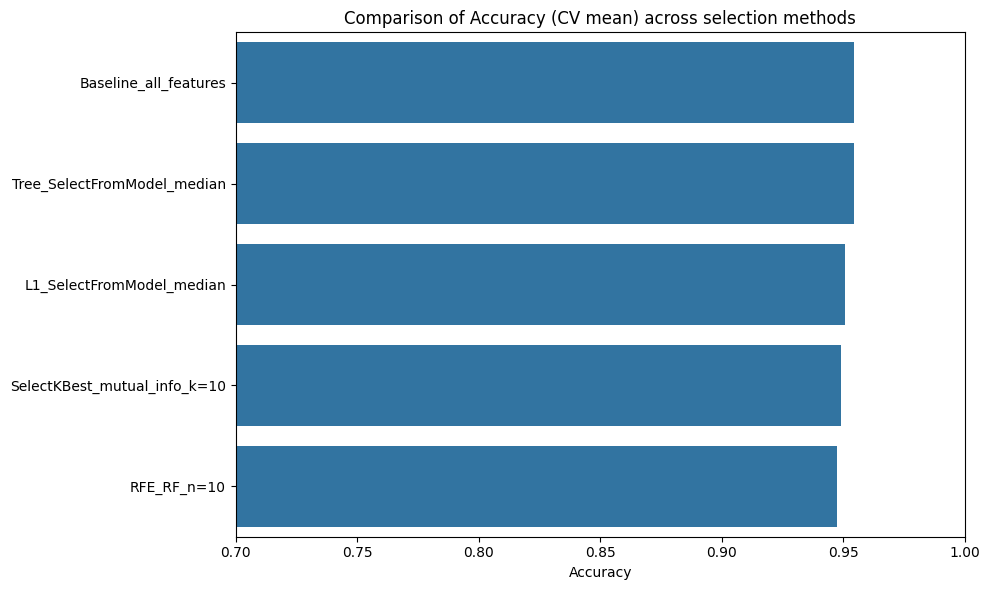

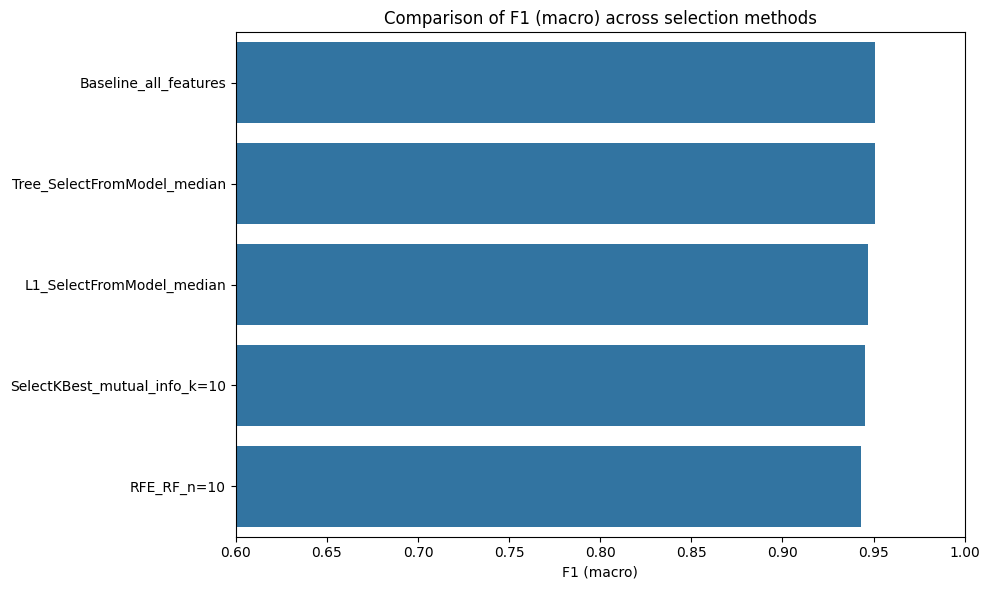

In [34]:
plt.figure(figsize=(10,6))
# Plot accuracy as a grouped bar plot for clarity
acc_df = results_df.reset_index().rename(columns={'index':'method'})
sns.barplot(x='accuracy', y='method', data=acc_df.sort_values('accuracy', ascending=False))
plt.title('Comparison of Accuracy (CV mean) across selection methods')
plt.xlabel('Accuracy')
plt.ylabel('')
plt.xlim(0.7, 1.0)
plt.tight_layout()
plt.show()

# Also show F1 for class-level balance
plt.figure(figsize=(10,6))
sns.barplot(x='f1', y='method', data=acc_df.sort_values('f1', ascending=False))
plt.title('Comparison of F1 (macro) across selection methods')
plt.xlabel('F1 (macro)')
plt.ylabel('')
plt.xlim(0.6, 1.0)
plt.tight_layout()
plt.show()


In [35]:
feature_names = X.columns.tolist()

# Fit and show selected features for SelectKBest
sel_kbest = SelectKBest(score_func=mutual_info_classif, k=k)
sel_kbest.fit(StandardScaler().fit_transform(X), y)
kbest_features = [f for f, s in zip(feature_names, sel_kbest.get_support()) if s]
print("SelectKBest features:", kbest_features)

# Fit RFE (on full data)
rfe_full = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=n_features_to_select)
rfe_full.fit(StandardScaler().fit_transform(X), y)
rfe_features = [f for f, s in zip(feature_names, rfe_full.get_support()) if s]
print("RFE selected features:", rfe_features)

# Fit L1 selector (Logistic L1)
l1_model = SelectFromModel(LogisticRegression(penalty='l1', solver='saga', max_iter=5000, random_state=42), threshold='median')
l1_model.fit(StandardScaler().fit_transform(X), y)
l1_features = [f for f, s in zip(feature_names, l1_model.get_support()) if s]
print("L1 SelectFromModel features:", l1_features)

# Tree-based SelectFromModel on full data
tree_model = SelectFromModel(RandomForestClassifier(n_estimators=200, random_state=42), threshold='median')
tree_model.fit(X, y)  # tree methods don't require scaling
tree_features = [f for f, s in zip(feature_names, tree_model.get_support()) if s]
print("Tree SelectFromModel features:", tree_features)


SelectKBest features: ['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'area error', 'worst radius', 'worst perimeter', 'worst area', 'worst concave points']
RFE selected features: ['mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']
L1 SelectFromModel features: ['mean concave points', 'mean fractal dimension', 'radius error', 'texture error', 'smoothness error', 'compactness error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst concavity', 'worst concave points', 'worst symmetry']
Tree SelectFromModel features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean compactness', 'mean concavity', 'mean concave points', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst compactness', 'worst concavit